In [1]:
import numba as nb
import numpy as np
import cupy as cp
# import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba import config
import math
import scipy.fft

config.CUDA_ENABLE_PYNVJITLINK = 1

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

Implemente operaciones básicas en 2D sobre una imagen sintética (tamaños: N ∈ {1024, 2048, 4096, 8192}).
a) Genere una imagen con varias fuentes puntuales y una gaussiana extendida.

In [3]:
%%time

def gaussian_2d(desv_est, size_x, size_y, brightness):
    gauss_image = np.zeros((size_x, size_y))
    center = (size_x // 2, size_y // 2)

    x = np.arange(size_x)
    y = np.arange(size_y)
    x_grid, y_grid = np.meshgrid(x, y)

    gauss_image = brightness * np.exp(
                -((x_grid - center[0])**2 + (y_grid - center[1])**2)/(2 * desv_est**2)
            )
    return gauss_image

def generate_image(N, N_points, brightness):
  img = gaussian_2d(100, N, N, brightness)
  random_pos = np.random.randint(0, N, (2, N_points))
  img[random_pos[0], random_pos[1]] = brightness
  return img

# plt.imshow(generate_image(1024, 200, 255))


CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 6.2 μs


b) Aplique ufuncs y filtros simples (p.ej., I 7→ log(1 + I); convolución 2D con kernel pequeño
5 × 5).

In [4]:
%%time

def convolve_in_fourier(img, kernel):
    img_x, img_y = img.shape
    kernel_x, kernel_y = kernel.shape
    padd_x = img_x - kernel_x
    padd_y = img_y - kernel_y

    kernel = np.pad(kernel, pad_width=((padd_x//2, padd_x//2),(padd_y//2, padd_y//2)), mode='constant')

    fft_image = np.fft.fft2(img)
    fft_kernel = np.fft.fft2(kernel)
    fft_convol = fft_image * fft_kernel

    return np.fft.fftshift(np.fft.ifft2(fft_convol)).real

kernel = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

kernel1 = np.array([
    [-1, 0, 0, 0, 1],
    [-1, 0, 0, 0, 1],
    [-1, 0, 0, 0, 1],
    [-1, 0, 0, 0, 1],
    [-1, 0, 0, 0, 1]
])

img = generate_image(1023, 200, 255)
# plt.imshow(convolve_in_fourier(img, kernel))

CPU times: user 10.2 ms, sys: 3.01 ms, total: 13.2 ms
Wall time: 12.9 ms


In [5]:
%%time

img = generate_image(1023, 200, 255)
# plt.imshow(np.log(1 + img))

CPU times: user 3.92 ms, sys: 3.07 ms, total: 6.99 ms
Wall time: 6.49 ms


c) Compare: NumPy (CPU) vs CuPy (GPU). Reporte tiempos y speedup = tCP U /tGP U .

In [6]:
%%time

def gaussian_2d(desv_est, size_x, size_y, brightness):
    gauss_image = cp.zeros((size_x, size_y))
    center = (size_x // 2, size_y // 2)

    x = cp.arange(size_x)
    y = cp.arange(size_y)
    x_grid, y_grid = cp.meshgrid(x, y)

    gauss_image = brightness * cp.exp(
                -((x_grid - center[0])**2 + (y_grid - center[1])**2)/(2 * desv_est**2)
            )
    return gauss_image

def generate_image(N, N_points, brightness):
  img = gaussian_2d(100, N, N, brightness)
  random_pos = cp.random.randint(0, N, (2, N_points))
  img[random_pos[0], random_pos[1]] = brightness
  return img

# plt.imshow(generate_image(1024, 200, 255).get())

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 4.29 μs


In [7]:
%%time

def convolve_in_fourier(img, kernel):
    img_x, img_y = img.shape
    kernel_x, kernel_y = kernel.shape
    padd_x = img_x - kernel_x
    padd_y = img_y - kernel_y

    kernel = cp.pad(kernel, pad_width=((padd_x//2, padd_x//2),(padd_y//2, padd_y//2)), mode='constant')

    fft_image = cp.fft.fft2(img)
    fft_kernel = cp.fft.fft2(kernel)
    fft_convol = fft_image * fft_kernel

    return cp.fft.fftshift(cp.fft.ifft2(fft_convol)).real

kernel = cp.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

kernel1 = cp.array([
    [-1, 0, 0, 0, 1],
    [-1, 0, 0, 0, 1],
    [-1, 0, 0, 0, 1],
    [-1, 0, 0, 0, 1],
    [-1, 0, 0, 0, 1]
])

img = generate_image(1023, 200, 255)
# plt.imshow(convolve_in_fourier(img, kernel).get())

CPU times: user 35.3 ms, sys: 95.4 ms, total: 131 ms
Wall time: 139 ms


In [8]:
%%time

img = generate_image(1023, 200, 255)
# plt.imshow(cp.log(1 + img).get())

CPU times: user 1.22 ms, sys: 876 μs, total: 2.1 ms
Wall time: 1.75 ms


## Ejercicio 3: Gridding con Numba–CUDA (no uniforme uv)

In [9]:
def generate_complex_points(shape, low=-10.0, high=10.0, dtype=np.float64):
    real_part = np.random.uniform(low, high, shape).astype(dtype)
    imag_part = np.random.uniform(low, high, shape).astype(dtype)
    return real_part + 1j * imag_part


def grid_visibilities_cpu(V, uvw_lambda, omega, du, dv, Npix=256):
    """
    V : np.ndarray
        Complex visibilities, shape (T, B, F).
    uvw_lambda : np.ndarray
        UVW coordinates in wavelengths, shape (T, B, F, 3).
    omega : np.ndarray
        Weights for each visibility, shape (T, B, F).
    du, dv : float
        Cell spacing in u and v directions.
    Npix : int
        Grid size (Npix x Npix).
    """

    n_times, n_baselines, n_freqs, _ = uvw_lambda.shape
    VG = np.zeros((Npix, Npix, n_freqs), dtype=np.complex128)
    WG = np.zeros((Npix, Npix, n_freqs), dtype=np.float64)

    # Loop over all dimensions (explicit CPU version)
    for f in range(n_freqs):
        for t in range(n_times):
            for b in range(n_baselines):
                u = uvw_lambda[t, b, f, 0]
                v = uvw_lambda[t, b, f, 1]
                V_val = V[t, b, f]
                w_val = omega[t, b, f]

                # Compute grid indices according to the equations:
                i = int(round(u / du + Npix / 2))
                j = int(round(v / dv + Npix / 2))

                # Only accumulate if inside grid boundaries
                if 0 <= i < Npix and 0 <= j < Npix:
                    VG[j, i, f] += w_val * V_val
                    WG[j, i, f] += w_val

    # Normalize grid cells with nonzero weights
    for f in range(n_freqs):
        for i in range(Npix):
            for j in range(Npix):
                if WG[j, i, f] > 0:
                    VG[j, i, f] /= WG[j, i, f]

    return VG, WG

def grid_visibilities_cpu_KernelKB(V, uvw_lambda, omega, du, dv, kernel, Npix=256):
    """
    V : np.ndarray
        Complex visibilities, shape (T, B, F).
    uvw_lambda : np.ndarray
        UVW coordinates in wavelengths, shape (T, B, F, 3).
    omega : np.ndarray
        Weights for each visibility, shape (T, B, F).
    du, dv : float
        Cell spacing in u and v directions.
    Npix : int
        Grid size (Npix x Npix).
    """

    n_times, n_baselines, n_freqs, _ = uvw_lambda.shape
    kernel_x, kernel_y = kernel.shape
    half_x = kernel_x // 2
    half_y = kernel_y // 2
    VG = np.zeros((Npix, Npix, n_freqs), dtype=np.complex128)
    WG = np.zeros((Npix, Npix, n_freqs), dtype=np.float64)

    # Loop over all dimensions (explicit CPU version)
    for f in range(n_freqs):
        for t in range(n_times):
            for b in range(n_baselines):
                u = uvw_lambda[t, b, f, 0]
                v = uvw_lambda[t, b, f, 1]
                V_val = V[t, b, f]
                w_val = omega[t, b, f]

                # Compute grid indices according to the equations:
                center_i = int(round(u / du + Npix / 2))
                center_j = int(round(v / dv + Npix / 2))

                # Check that center is not out of bounds
                if 0 <= center_i < Npix and 0 <= center_j < Npix:

                  # Iterate over kernel
                  for k_i in range(kernel_x):
                    for k_j in range(kernel_y):
                      idx_i = center_i + (k_i - half_x)
                      idx_j = center_j + (k_j - half_y)

                      # Check if kernel is not out of bounds
                      if 0 <= idx_i < Npix and 0 <= idx_j < Npix:
                        VG[idx_j, idx_i, f] += w_val * V_val * kernel[k_i, k_j]
                        WG[idx_j, idx_i, f] += w_val * kernel[k_i, k_j]

    # Normalize grid cells with nonzero weights
    for f in range(n_freqs):
        for i in range(Npix):
            for j in range(Npix):
                if WG[j, i, f] > 0:
                    VG[j, i, f] /= WG[j, i, f]

    return VG, WG

def grid_visibilities(V, uvw_lambda, omega, du, dv, Npix=256):
    """
    V : np.ndarray
        Complex visibilities, shape (..., F)
    uvw_lambda : np.ndarray
        UVW coordinates in wavelengths, shape (..., F, 3)
    du, dv : float
        Grid spacing in u and v directions
    omega : np.ndarray
        Weights for each visibility, same shape as V
    Npix : int
        Grid size (NxN)
    """

    n_freqs = V.shape[-1]
    u_coords = uvw_lambda[..., 0]
    v_coords = uvw_lambda[..., 1]

    VG = np.zeros((Npix, Npix, n_freqs), dtype=np.complex128)
    WG = np.zeros((Npix, Npix, n_freqs), dtype=np.float64)

    for f in range(n_freqs):
        u_f = u_coords[..., f].ravel()
        v_f = v_coords[..., f].ravel()
        V_f = V[..., f].ravel()

        omega_f = omega[..., f].ravel()

        # Compute grid indices as per document equations
        i = np.rint(u_f / du).astype(int) + Npix // 2
        j = np.rint(v_f / dv).astype(int) + Npix // 2

        # Only keep valid cells inside grid boundaries
        mask = (i >= 0) & (i < Npix) & (j >= 0) & (j < Npix)

        # Weighted accumulation
        np.add.at(VG[..., f], (j[mask], i[mask]), omega_f[mask] * V_f[mask])
        np.add.at(WG[..., f], (j[mask], i[mask]), omega_f[mask])

    # Normalize where weights are nonzero
    valid_cells = WG > 0
    VG[valid_cells] /= WG[valid_cells]

    return VG, WG


@cuda.jit
def _grid_kernel(u, v, V_real, V_imag, omega, du, dv, VG_real, VG_imag, WG, Npix):
    """
    GPU kernel: each thread accumulates one visibility onto the nearest pixel.
    """
    idx = cuda.grid(1)
    n = u.size
    if idx >= n:
        return

    # Compute grid coordinates
    i = int(math.floor(u[idx] / du + 0.5)) + Npix // 2
    j = int(math.floor(v[idx] / dv + 0.5)) + Npix // 2

    # Ignore visibilities outside grid bounds
    if i < 0 or i >= Npix or j < 0 or j >= Npix:
        return

    w = omega[idx]
    cuda.atomic.add(VG_real, (j, i), w * V_real[idx])
    cuda.atomic.add(VG_imag, (j, i), w * V_imag[idx])
    cuda.atomic.add(WG, (j, i), w)

@cuda.jit
def _grid_kernel_KB(u, v, V_real, V_imag, omega, du, dv, kernel, VG_real, VG_imag, WG, Npix):
    """
    GPU kernel for gridding using a 2D convolutional kernel (e.g., Kaiser–Bessel).
    Each thread grids one visibility over a kernel footprint.
    """
    idx = cuda.grid(1)
    n = u.size
    if idx >= n:
        return

    # Compute the central grid coordinates for this visibility
    center_i = int(math.floor(u[idx] / du + 0.5)) + Npix // 2
    center_j = int(math.floor(v[idx] / dv + 0.5)) + Npix // 2

    # Skip visibilities completely outside grid bounds
    if center_i < 0 or center_i >= Npix or center_j < 0 or center_j >= Npix:
        return

    kernel_x, kernel_y = kernel.shape
    half_x = kernel_x // 2
    half_y = kernel_y // 2

    vis_real = V_real[idx]
    vis_imag = V_imag[idx]
    w = omega[idx]

    # Apply convolution kernel centered at (center_i, center_j)
    for k_i in range(kernel_x):
        for k_j in range(kernel_y):
            # Compute target pixel coordinates
            i = center_i + (k_i - half_x)
            j = center_j + (k_j - half_y)

            # Check grid boundaries
            if 0 <= i < Npix and 0 <= j < Npix:
                weight = w * kernel[k_i, k_j]

                cuda.atomic.add(VG_real, (j, i), weight * vis_real)
                cuda.atomic.add(VG_imag, (j, i), weight * vis_imag)
                cuda.atomic.add(WG, (j, i), weight)



def grid_visibilities_cuda(V, uvw_lambda, omega, du, dv, Npix=256, threads_per_block=1024, conv_kernel=None):
    """
    GPU-accelerated version of grid_visibilities().
    Each frequency is processed independently, just like the CPU version.
    """
    n_freqs = V.shape[-1]
    VG = np.zeros((Npix, Npix, n_freqs), dtype=np.complex128)
    WG = np.zeros((Npix, Npix, n_freqs), dtype=np.float64)

    for f in range(n_freqs):
        # Flatten per-frequency arrays
        u_f = np.ascontiguousarray(uvw_lambda[..., f, 0].ravel())
        v_f = np.ascontiguousarray(uvw_lambda[..., f, 1].ravel())
        V_f = np.ascontiguousarray(V[..., f].ravel())
        omega_f = np.ascontiguousarray(omega[..., f].ravel())

        n_vis = u_f.size

        # Allocate GPU arrays
        d_u = cuda.to_device(u_f)
        d_v = cuda.to_device(v_f)
        d_V_real = cuda.to_device(np.ascontiguousarray(V_f.real))
        d_V_imag = cuda.to_device(np.ascontiguousarray(V_f.imag))
        d_omega = cuda.to_device(omega_f)

        d_VG_real = cuda.device_array((Npix, Npix), dtype=np.float64)
        d_VG_imag = cuda.device_array((Npix, Npix), dtype=np.float64)
        d_WG = cuda.device_array((Npix, Npix), dtype=np.float64)

        # Initialize grids to zero
        d_VG_real[:] = 0
        d_VG_imag[:] = 0
        d_WG[:] = 0

        # Launch kernel
        blocks_per_grid = (n_vis + threads_per_block - 1) // threads_per_block

        if conv_kernel is not None:
            d_kernel = cuda.to_device(np.ascontiguousarray(conv_kernel))
            _grid_kernel_KB[blocks_per_grid, threads_per_block](
                d_u, d_v, d_V_real, d_V_imag, d_omega,
                du, dv, d_kernel, d_VG_real, d_VG_imag, d_WG, Npix
            )
        else:
          _grid_kernel[blocks_per_grid, threads_per_block](
            d_u, d_v, d_V_real, d_V_imag, d_omega,
            du, dv, d_VG_real, d_VG_imag, d_WG, Npix
        )

        # Copy results back
        VG_real = d_VG_real.copy_to_host()
        VG_imag = d_VG_imag.copy_to_host()
        WG_f = d_WG.copy_to_host()

        # Normalize (on CPU)
        mask = WG_f > 0
        VG[..., f][mask] = (VG_real[mask] + 1j * VG_imag[mask]) / WG_f[mask]
        WG[..., f] = WG_f

    return VG, WG

Implemente gridding por vecino más cercano (NN) de visibilidades no regulares sobre una
malla uv.

a) Versión CPU (doble bucle) como referencia y validación.

In [10]:
N_baselines = 100000
Npix = 1024
du = dv = 0.001

uv_weights = np.ones((1, N_baselines, 1))
visibilities = generate_complex_points((1, N_baselines, 1))
uv_coords = np.random.uniform(-1, 1, (1, N_baselines, 1, 3))

print("Shape Visibilities: ", visibilities.shape)
print("Shape UV Coords: ", uv_coords.shape)
print("Shape UV Weights: ", uv_weights.shape)

Shape Visibilities:  (1, 100000, 1)
Shape UV Coords:  (1, 100000, 1, 3)
Shape UV Weights:  (1, 100000, 1)


In [11]:
%%time
VG, WG = grid_visibilities(visibilities, uv_coords, uv_weights, du, dv, Npix)

# plt.imshow(VG.real, cmap="viridis", origin="lower", vmin=0.1)
# plt.colorbar()
# plt.tight_layout()
# plt.show()

CPU times: user 14.6 ms, sys: 2.1 ms, total: 16.7 ms
Wall time: 16.7 ms


b) Kernel Numba–CUDA que, por visibilidad, acumule en el píxel uv más cercano (con pesos
naturales). Evite colisiones con cuda.atomic.add.

In [12]:
%%time
VG, WG = grid_visibilities_cpu(visibilities, uv_coords, uv_weights, du, dv, Npix)

# plt.imshow(VG.real, cmap="viridis", origin="lower", vmin=0.1)
# plt.colorbar()
# plt.tight_layout()
# plt.show()

CPU times: user 228 ms, sys: 796 μs, total: 229 ms
Wall time: 227 ms


In [13]:
%%time
VG, WG = grid_visibilities_cuda(visibilities, uv_coords, uv_weights, du, dv, Npix)

# plt.imshow(VG.real, cmap="viridis", origin="lower", vmin=0.1)
# plt.colorbar()
# plt.tight_layout()
# plt.show()

/home/vcnt/y/envs/lab2_env/lib/python3.13/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 98 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


CPU times: user 193 ms, sys: 10.8 ms, total: 204 ms
Wall time: 203 ms


NvvmError: Failed to verify

error: Error: :  Function `_ZN8__main__12_grid_kernelB2v3B102cw51cXTLSUwv1sDUaKthaKSjYKCpo4DkeVtwuOooAA2wBSU0YECjxTmSMCR5IQmgJhmYBJIXbKvVYQGrbqUAjSB1oCSQZ1yrCQA_3dE5ArrayIdLi1E1C7mutable7alignedE5ArrayIdLi1E1C7mutable7alignedE5ArrayIdLi1E1C7mutable7alignedE5ArrayIdLi1E1C7mutable7alignedE5ArrayIdLi1E1C7mutable7alignedEdd5ArrayIdLi2E1C7mutable7alignedE5ArrayIdLi2E1C7mutable7alignedE5ArrayIdLi2E1C7mutable7alignedEx' Basic Block `B304': 
  context:   %0 = atomicrmw fadd ptr %.478, double %.444 seq_cst, align 8
  atomicrmw does not support operation: 'fadd'.


NVVM_ERROR_INVALID_IR

c) Compare tiempos para M visibilidades (p.ej. 105
, 106
) y resolución de malla. Reporte error

RMS entre CPU y GPU.

## Ejercicio 4: Convolutional gridding (Kaiser–Bessel)

In [ ]:
N_baselines = 100000
Npix = 1024
du = dv = 0.001

uv_weights = np.ones((1, N_baselines, 1))
visibilities = generate_complex_points((1, N_baselines, 1))
uv_coords = np.random.uniform(-1, 1, (1, N_baselines, 1, 3))

print("Shape Visibilities: ", visibilities.shape)
print("Shape UV Coords: ", uv_coords.shape)
print("Shape UV Weights: ", uv_weights.shape)

kernel = np.array(
    [[1, 1, 1],
     [1, 1, 1],
     [1, 1, 1]]
    )

Shape Visibilities:  (1, 100000, 1)
Shape UV Coords:  (1, 100000, 1, 3)
Shape UV Weights:  (1, 100000, 1)


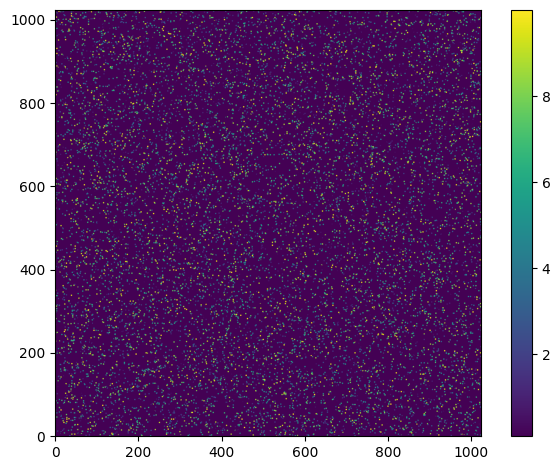

CPU times: total: 1.39 s
Wall time: 1.41 s


In [ ]:
%%time
VG, WG = grid_visibilities_cpu_KernelKB(visibilities, uv_coords, uv_weights, du, dv, kernel, Npix)

plt.imshow(VG.real, cmap="viridis", origin="lower", vmin=0.1)
plt.colorbar()
plt.tight_layout()
plt.show()

D:\Proyectos Informatica\Python Projects\CUDA_Proyects\.venv\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 98 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


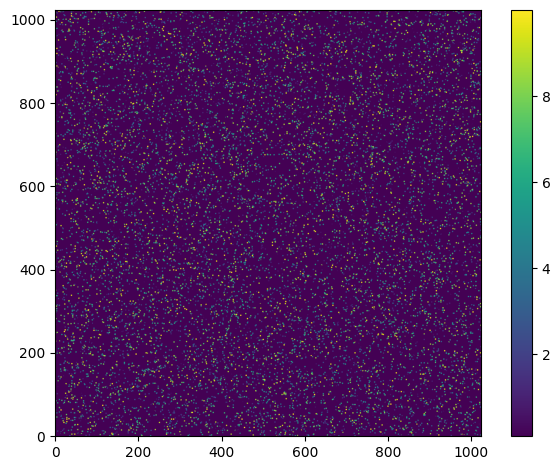

CPU times: total: 312 ms
Wall time: 311 ms


In [ ]:
%%time
VG, WG = grid_visibilities_cuda(visibilities, uv_coords, uv_weights, du, dv, Npix, conv_kernel=kernel)

plt.imshow(VG.real, cmap="viridis", origin="lower", vmin=0.1)
plt.colorbar()
plt.tight_layout()
plt.show()